In [1]:
## Cell 1: import necessary libraries

# Data analysis and processing
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from bokeh.plotting import figure, output_file, show, save
from bokeh.models import ColumnDataSource, HoverTool, Select, Slider, RangeSlider, TapTool, Div
from bokeh.layouts import column, row
from bokeh.palettes import Category20
from bokeh.transform import factor_cmap

# Ensure charts are embedded in Jupyter
from bokeh.io import output_notebook
output_notebook()

Loading BokehJS ...

In [2]:
## Cell 2: load and examine the dataset

# Load Gapminder dataset
print("Loading dataset...")
data = pd.read_csv('gapminder.csv')

# Display basic dataset information
print("="*60)
print("Dataset Basic Information:")
print(f"Data shape: {data.shape}")
print(f"Time range: {data['Year'].min()} to {data['Year'].max()}")
print(f"Number of countries: {data['Country'].nunique()}")
print(f"Number of regions: {data['Region'].nunique()}")

# Display first few rows
print("\nFirst 5 rows of data:")
display(data.head())

# Display column information
print("\nColumn names and data types:")
print(data.dtypes)

# Check for missing values
print("\nMissing values statistics:")
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0])

# Data statistical summary
print("\nNumerical columns statistical summary:")
display(data[['lifeExp', 'Fertility', 'pop']].describe())

Loading dataset...
Dataset Basic Information:
Data shape: (12200, 7)
Time range: 1964 to 2013
Number of countries: 244
Number of regions: 6

First 5 rows of data:


,Country,Year,lifeExp,pop,Fertility,Region,ID
0,Afghanistan,1964,33.639,10474903.0,7.671,South Asia,AF
1,Afghanistan,1965,34.152,10697983.0,7.671,South Asia,AF
2,Afghanistan,1966,34.662,10927724.0,7.671,South Asia,AF
3,Afghanistan,1967,35.170,11163656.0,7.671,South Asia,AF
4,Afghanistan,1968,35.674,11411022.0,7.671,South Asia,AF



Column names and data types:
Country          str
Year           int64
lifeExp      float64
pop          float64
Fertility    float64
Region           str
ID               str
dtype: object

Missing values statistics:
lifeExp      2089
pop           394
Fertility    2100
ID             50
dtype: int64

Numerical columns statistical summary:


,lifeExp,Fertility,pop
count,10111.000000,10100.000000,1.180600e+04
mean,64.078600,4.028719,2.196105e+07
std,11.122779,2.013968,9.593930e+07
min,6.000000,0.836000,5.000000e+01
25%,56.282500,2.175750,2.516718e+05
50%,67.157000,3.632500,3.497884e+06
75%,72.484000,5.905250,1.139999e+07
max,83.580000,9.223000,1.359368e+09


In [3]:
## Cell 3: Data Preprocessing and Preparation

# Copy original data
df = data.copy()

# 1. Handle missing values
print("Handling missing values...")
initial_rows = len(df)
df = df.dropna()  # Remove rows with missing values
final_rows = len(df)
print(f"Removed missing values: from {initial_rows} rows to {final_rows} rows")

# 2. Convert data types
df['Year'] = df['Year'].astype(int)
df['lifeExp'] = df['lifeExp'].astype(float)
df['Fertility'] = df['Fertility'].astype(float)
df['pop'] = df['pop'].astype(float)  # prevent overflow

# 3. Create derived features
# Calculate relative population for each country each year (for point size scaling)
df['pop_scaled'] = df['pop'] / df['pop'].max() * 100  # Scale to 0-100 range

# Calculate development index for each country each year (simple composite metric)
df['development_index'] = (df['lifeExp'] / df['lifeExp'].max() + 
                           (1 - df['Fertility'] / df['Fertility'].max())) / 2

# 4. Prepare color mapping for Bokeh
# Create color mapping for each region
regions = sorted(df['Region'].unique())
region_colors = Category20[len(regions)]
print(f"Exported region color mapping: {len(region_colors)} colors")

# 5. Prepare data structure for animation
# Create independent datasets for each year
years = sorted(df['Year'].unique())
year_data = {}
for year in years:
    year_data[year] = df[df['Year'] == year]

print(f"\nData processing completed!")
print(f"Final data shape: {df.shape}")
print(f"Year range: {years[0]} to {years[-1]}")
print(f"Region list: {regions}")

Handling missing values...
Removed missing values: from 12200 rows to 10050 rows
Exported region color mapping: 6 colors

Data processing completed!
Final data shape: (10050, 9)
Year range: 1964 to 2013
Region list: ['America', 'East Asia & Pacific', 'Europe & Central Asia', 'Middle East & North Africa', 'South Asia', 'Sub-Saharan Africa']


In [4]:
## Cell 4: Create Bokeh Data Sources and Interactive Controls
from bokeh.models import Button

# Create initial data source (display 1964 data)
initial_year = 1964
initial_data = df[df['Year'] == initial_year]

# Create ColumnDataSource for main scatter plot
scatter_source = ColumnDataSource(data=dict(
    Country=initial_data['Country'],
    Region=initial_data['Region'],
    Fertility=initial_data['Fertility'],
    lifeExp=initial_data['lifeExp'],
    pop=initial_data['pop'],
    pop_scaled=initial_data['pop_scaled'],
    Year=initial_data['Year']
))

# Create timeline slider
year_slider = Slider(start=years[0], end=years[-1], 
                     value=initial_year, step=1, 
                     title="Year", 
                     width=600)

# Create region selector
region_select = Select(title="Select Region", 
                       value="All", 
                       options=["All"] + list(regions),
                       width=100)

# Create country search box
country_search = Select(title="Search Country", 
                        value="All", 
                        options=["All"] + sorted(df['Country'].unique().tolist()),
                        width=100)

# Create population range slider
pop_slider = RangeSlider(start=df['pop'].min(), end=df['pop'].max(),
                         value=(df['pop'].min(), df['pop'].max()), 
                         step=1000000, 
                         title="Population Range",
                         width=300)

# Create autoplay button (using Button model)
autoplay_button = Button(label="▶ Autoplay", 
                         button_type="primary", 
                         width=200)

print("Interactive controls created!")
print(f"Initial year: {initial_year}")
print(f"Number of regions: {len(regions)}")
print(f"Control panel includes: year slider, region selector, country search box, population range slider, autoplay button")

Interactive controls created!
Initial year: 1964
Number of regions: 6
Control panel includes: year slider, region selector, country search box, population range slider, autoplay button


In [5]:
## Cell 5: Create Main Scatter Plot

# Create scatter plot
p = figure(title="Global Fertility Rate vs. Life Expectancy Relationship (1964-2013)", 
           x_axis_label="Fertility Rate (births/woman)", 
           y_axis_label="Life Expectancy (years)",
           width=800, height=600,
           tools="pan,wheel_zoom,box_zoom,reset,save,tap",
           toolbar_location="above")

# Create color mapping
color_mapper = factor_cmap(field_name='Region', 
                          palette=region_colors[:len(regions)],
                          factors=regions)

# Draw scatter points
scatter = p.scatter('Fertility', 'lifeExp', 
                    size='pop_scaled',
                    source=scatter_source,
                    fill_color=color_mapper,
                    fill_alpha=0.7,
                    line_color='white',
                    line_width=0.5,
                    legend_field='Region',
                    selection_color='orange',
                    nonselection_fill_alpha=0.2,
                    nonselection_line_alpha=0.1)

# Set axis ranges
p.x_range.start = df['Fertility'].min() - 0.5
p.x_range.end = df['Fertility'].max() + 0.5
p.y_range.start = df['lifeExp'].min() - 5
p.y_range.end = df['lifeExp'].max() + 5

# Add hover tool
hover = HoverTool()
hover.tooltips = [
    ("Country", "@Country"),
    ("Region", "@Region"),
    ("Year", "@Year"),
    ("Fertility Rate", "@Fertility{0.2f}"),
    ("Life Expectancy", "@lifeExp{0.1f} years"),
    ("Population", "@pop{0,0}")
]
p.add_tools(hover)

# Add click selection tool
tap = TapTool()
p.add_tools(tap)

# Set chart styles
p.title.text_font_size = "16pt"
p.xaxis.axis_label_text_font_size = "12pt"
p.yaxis.axis_label_text_font_size = "12pt"
p.legend.title = "Region"
p.legend.location = "top_right"
p.legend.click_policy = "hide"

# Add average lines (reference lines)
avg_fertility = df['Fertility'].mean()
avg_lifeexp = df['lifeExp'].mean()
p.line([avg_fertility, avg_fertility], [p.y_range.start, p.y_range.end], 
       line_color='gray', line_dash='dashed', line_width=1, alpha=0.5)
p.line([p.x_range.start, p.x_range.end], [avg_lifeexp, avg_lifeexp], 
       line_color='gray', line_dash='dashed', line_width=1, alpha=0.5)

print("Main scatter plot created!")
print(f"X-axis: Fertility Rate ({df['Fertility'].min():.2f} to {df['Fertility'].max():.2f})")
print(f"Y-axis: Life Expectancy ({df['lifeExp'].min():.1f} to {df['lifeExp'].max():.1f})")
print(f"Point size: Population (scaled)")
print(f"Point color: Region ({len(regions)} regions)")

Main scatter plot created!
X-axis: Fertility Rate (0.84 to 9.22)
Y-axis: Life Expectancy (6.0 to 83.6)
Point size: Population (scaled)
Point color: Region (6 regions)


In [6]:
## Cell 6: Create Linked Line Chart (Modified)
from bokeh.models import LinearAxis

# 1. Create empty line chart data source
# Initially show no country, wait for user selection
line_source = ColumnDataSource(data=dict(
    Year=[],
    Fertility=[],
    lifeExp=[],
    pop=[],
    Country=[],
    Region=[]
))

# 2. Create dual Y-axis line chart
p_line = figure(title="Please select a country to view its 50-year trend", 
                x_axis_label="Year",
                width=800, height=300,
                tools="pan,wheel_zoom,box_zoom,reset,save",
                toolbar_location="above",
                x_range=(df['Year'].min(), df['Year'].max()))

# Initially draw no lines, wait for data
# Fertility line (left Y-axis)
fertility_line = p_line.line('Year', 'Fertility', source=line_source, 
                             line_width=2, color='red', 
                             legend_label="Fertility Rate", 
                             alpha=0.8, visible=False)  # Initially invisible

# Add fertility points
fertility_scatter = p_line.scatter('Year', 'Fertility', source=line_source,
                                   size=6, color='red', alpha=0.6, visible=False)

# Life expectancy line (right Y-axis)
# Create second Y-axis range
p_line.extra_y_ranges = {"lifeExp_range": p_line.y_range}
# Add second Y-axis
lifeexp_axis = LinearAxis(axis_label="Life Expectancy (years)", y_range_name="lifeExp_range")
p_line.add_layout(lifeexp_axis, 'right')

# Draw life expectancy line
lifeexp_line = p_line.line('Year', 'lifeExp', source=line_source, 
                           line_width=2, color='blue', 
                           legend_label="Life Expectancy",
                           y_range_name="lifeExp_range", alpha=0.8, visible=False)

# Add life expectancy points
lifeexp_scatter = p_line.scatter('Year', 'lifeExp', source=line_source,
                                 size=6, color='blue', alpha=0.6,
                                 y_range_name="lifeExp_range", visible=False)

# 3. Set Y-axis labels
p_line.yaxis.axis_label = "Fertility Rate"

# 4. Set legend
p_line.legend.location = "top_right"
p_line.legend.click_policy = "hide"

# 5. Add hover tool
line_hover = HoverTool(
    renderers=[fertility_line, lifeexp_line],
    tooltips=[
        ("Country", "@Country"),
        ("Region", "@Region"),
        ("Year", "@Year"),
        ("Fertility Rate", "@Fertility{0.2f}"),
        ("Life Expectancy", "@lifeExp{0.1f} years"),
        ("Population", "@pop{0,0}")
    ],
    mode='mouse'
)
p_line.add_tools(line_hover)

# 6. Set axis ranges
# Get min/max of all countries' fertility rates to set reasonable Y-axis range for line chart
fertility_min = df['Fertility'].min() - 0.5
fertility_max = df['Fertility'].max() + 0.5
lifeexp_min = df['lifeExp'].min() - 5
lifeexp_max = df['lifeExp'].max() + 5

p_line.y_range.start = fertility_min
p_line.y_range.end = fertility_max
p_line.extra_y_ranges["lifeExp_range"].start = lifeexp_min
p_line.extra_y_ranges["lifeExp_range"].end = lifeexp_max

print("Dynamic linked line chart created!")

Dynamic linked line chart created!


In [7]:
## Cell 7: Create Region Comparison Chart (Fixed Y-axis index error)

# 1. Calculate region average data
region_avg = df.groupby(['Region', 'Year']).agg({
    'Fertility': 'mean',
    'lifeExp': 'mean',
    'pop': 'sum'
}).reset_index()

# 2. Create region comparison chart
p_region = figure(title="Region Average Trend Comparison", 
                  x_axis_label="Year",
                  y_axis_label="Value",
                  width=800, height=500,
                  tools="pan,wheel_zoom,box_zoom,reset,save",
                  toolbar_location="above")

# 3. Draw fertility trend lines for each region
for i, region in enumerate(regions):
    region_data = region_avg[region_avg['Region'] == region]
    p_region.line(region_data['Year'], region_data['Fertility'], 
                  line_width=2, color=region_colors[i], 
                  legend_label=f"{region} (Fertility)", alpha=0.7)

# 4. Create second Y-axis for life expectancy
# First set extra Y-axis range
p_region.extra_y_ranges = {"lifeExp_range": p_region.y_range}

# Then create and add second Y-axis
lifeexp_axis = LinearAxis(axis_label="Life Expectancy (years)", y_range_name="lifeExp_range")
p_region.add_layout(lifeexp_axis, 'right')

# 5. Draw life expectancy trend lines for each region (dashed)
for i, region in enumerate(regions):
    region_data = region_avg[region_avg['Region'] == region]
    p_region.line(region_data['Year'], region_data['lifeExp'], 
                  line_width=2, color=region_colors[i], 
                  legend_label=f"{region} (Life Expectancy)",
                  line_dash='dashed', alpha=0.7,
                  y_range_name="lifeExp_range")

# 6. Set legend
p_region.legend.location = "top_right"
p_region.legend.click_policy = "hide"

# 7. Set hover tool
region_hover = HoverTool()
region_hover.tooltips = [
    ("Region", "$name"),
    ("Year", "@x"),
    ("Value", "@y{0.2f}")
]
p_region.add_tools(region_hover)

print("Region comparison chart created!")
print(f"Compared average trends of fertility and life expectancy for {len(regions)} regions")

Region comparison chart created!
Compared average trends of fertility and life expectancy for 6 regions


In [8]:
## Cell 8: Implement Pure JavaScript Callback Functions (Complete fixed version)
from bokeh.models import CustomJS
from bokeh.events import Tap

# 1. Prepare complete data source
# Create complete data source containing all years' data
full_data_source = ColumnDataSource(data=dict(
    Country=df['Country'],
    Region=df['Region'],
    Fertility=df['Fertility'],
    lifeExp=df['lifeExp'],
    pop=df['pop'],
    pop_scaled=df['pop_scaled'],
    Year=df['Year']
))

# 2. Scatter plot update callback - Complete JavaScript implementation
update_scatter_js = """
// Get control values
const year = year_slider.value;
const region = region_select.value;
const country = country_search.value;
const [pop_min, pop_max] = [pop_slider.value[0], pop_slider.value[1]];

// Get data from complete data source
const all_data = full_data_source.data;
const new_data = {
    Country: [], Region: [], Fertility: [], lifeExp: [], 
    pop: [], pop_scaled: [], Year: []
};

// Filter data
for (let i = 0; i < all_data.Year.length; i++) {
    const year_match = (all_data.Year[i] === year);
    const region_match = (region === "All") || (all_data.Region[i] === region);
    const country_match = (country === "All") || (all_data.Country[i] === country);
    const pop_match = (all_data.pop[i] >= pop_min && all_data.pop[i] <= pop_max);
    
    if (year_match && region_match && country_match && pop_match) {
        new_data.Country.push(all_data.Country[i]);
        new_data.Region.push(all_data.Region[i]);
        new_data.Fertility.push(all_data.Fertility[i]);
        new_data.lifeExp.push(all_data.lifeExp[i]);
        new_data.pop.push(all_data.pop[i]);
        new_data.pop_scaled.push(all_data.pop_scaled[i]);
        new_data.Year.push(all_data.Year[i]);
    }
}

// Update scatter plot data source
scatter_source.data = new_data;

// Update scatter plot title
p.title.text = `Global Fertility Rate vs. Life Expectancy Relationship (${year})`;

// If a country is selected, update line chart
if (country !== "All" || scatter_source.selected.indices.length > 0) {
    update_line_chart();
}
"""

# 3. Line chart update callback
line_update_js = """
// Define global line chart update function
function update_line_chart() {
    let selected_country = "";
    
    // First check search box
    if (country_search.value !== "All") {
        selected_country = country_search.value;
    } 
    // If no search box selection, check scatter plot selection
    else if (scatter_source.selected.indices.length > 0) {
        const idx = scatter_source.selected.indices[0];
        if (idx < scatter_source.data.Country.length) {
            selected_country = scatter_source.data.Country[idx];
        }
    }
    
    if (selected_country && selected_country !== "") {
        // Filter this country's data from complete data
        const all_data = full_data_source.data;
        const country_data = {
            Year: [], Fertility: [], lifeExp: [], pop: [], 
            Country: [], Region: []
        };
        
        for (let i = 0; i < all_data.Year.length; i++) {
            if (all_data.Country[i] === selected_country) {
                country_data.Year.push(all_data.Year[i]);
                country_data.Fertility.push(all_data.Fertility[i]);
                country_data.lifeExp.push(all_data.lifeExp[i]);
                country_data.pop.push(all_data.pop[i]);
                country_data.Country.push(all_data.Country[i]);
                country_data.Region.push(all_data.Region[i]);
            }
        }
        
        // Update line chart data source
        line_source.data = country_data;
        
        // Update line chart title
        p_line.title.text = `${selected_country}: Fertility Rate and Life Expectancy Trend (1964-2013)`;
        
        // Show line chart
        p_line.renderers[0].visible = true;  // Fertility line
        p_line.renderers[1].visible = true;  // Fertility scatter
        p_line.renderers[2].visible = true;  // Life expectancy line
        p_line.renderers[3].visible = true;  // Life expectancy scatter
        
        // Trigger data source update
        line_source.change.emit();
    } else {
        // If no country selected, clear line chart
        line_source.data = {
            Year: [], Fertility: [], lifeExp: [], pop: [], 
            Country: [], Region: []
        };
        
        // Update title
        p_line.title.text = "Please select a country to view its 50-year trend";
        
        // Hide line chart
        p_line.renderers[0].visible = false;
        p_line.renderers[1].visible = false;
        p_line.renderers[2].visible = false;
        p_line.renderers[3].visible = false;
        
        line_source.change.emit();
    }
}
"""

# 4. Autoplay callback
autoplay_js = """
// Global variable to track autoplay state
if (typeof window.autoplayState === 'undefined') {
    window.autoplayState = { playing: false, interval: null };
}

// Toggle autoplay state
if (!window.autoplayState.playing) {
    // Start playing
    window.autoplayState.playing = true;
    autoplay_button.label = "⏸ Stop";
    
    let year = year_slider.start;
    
    window.autoplayState.interval = setInterval(() => {
        if (year <= year_slider.end) {
            year_slider.value = year;
            year_slider.change.emit();
            year++;
        } else {
            // Playback complete, stop
            window.autoplayState.playing = false;
            clearInterval(window.autoplayState.interval);
            window.autoplayState.interval = null;
            autoplay_button.label = "▶ Autoplay";
        }
    }, 300); // Update every 300 milliseconds
} else {
    // Stop playing
    window.autoplayState.playing = false;
    if (window.autoplayState.interval) {
        clearInterval(window.autoplayState.interval);
        window.autoplayState.interval = null;
    }
    autoplay_button.label = "▶ Autoplay";
}
"""

# 5. Scatter plot click callback
tap_callback_js = """
// Get clicked index
const indices = scatter_source.selected.indices;
if (indices.length > 0) {
    const idx = indices[0];
    if (idx < scatter_source.data.Country.length) {
        const country = scatter_source.data.Country[idx];
        
        // Display selected country in search box
        country_search.value = country;
        
        // Update scatter plot (this triggers scatter plot update callback, which then updates line chart)
        year_slider.change.emit();
    }
}
"""

# 6. Create combined callback function
combined_callback_js = update_scatter_js + line_update_js

# Create callback objects
# Main callback function (includes scatter plot update and line chart update)
main_callback = CustomJS(args=dict(
    scatter_source=scatter_source,
    full_data_source=full_data_source,
    line_source=line_source,
    year_slider=year_slider,
    region_select=region_select,
    country_search=country_search,
    pop_slider=pop_slider,
    p=p,
    p_line=p_line
), code=combined_callback_js)

# Autoplay callback
autoplay_callback = CustomJS(args=dict(
    year_slider=year_slider,
    autoplay_button=autoplay_button
), code=autoplay_js)

# Scatter plot click callback
tap_callback = CustomJS(args=dict(
    scatter_source=scatter_source,
    country_search=country_search,
    year_slider=year_slider
), code=tap_callback_js)

# 7. Bind callbacks to controls
# Year slider
year_slider.js_on_change('value', main_callback)

# Region selector
region_select.js_on_change('value', main_callback)

# Country search box
country_search.js_on_change('value', main_callback)

# Population range slider
pop_slider.js_on_change('value', main_callback)

# Autoplay button
autoplay_button.js_on_event("button_click", autoplay_callback)

# 8. Bind scatter plot click event
p.js_on_event(Tap, tap_callback)

print("JavaScript callback functions set up!")

JavaScript callback functions set up!


In [9]:
## Cell 9: Create Control Panel and Layout

# Create title - center aligned, divider same width as window
title = Div(text="""
<div style="text-align: center; width: 100%; margin: 0 auto;">
<h1 style="margin-bottom: 10px;">Global Fertility Rate and Life Expectancy Visualization Analysis (1964-2013)</h1>
<p style="margin-top: 0; margin-bottom: 20px; font-size: 16px;">Explore the relationship between global fertility rates and life expectancy, analyze regional differences and development trends</p>
<hr style="width: 100%; border: 1px solid #ddd; margin: 20px 0;">
</div>
""", width=1000)

# Create control panel
controls_title = Div(text="<h3 style='margin-top: 0;'>Control Panel</h3>", width=300)

# Create a container for sliders with left margin
# Add margin-left to both sliders (reduced from 20px to 10px as requested)
year_slider_with_margin = column(year_slider, width=300, margin=(0, 0, 0, 10))
pop_slider_with_margin = column(pop_slider, width=300, margin=(0, 0, 0, 10))

controls = column(
    controls_title,
    year_slider_with_margin,  # Use slider with margin
    row(region_select, country_search, margin=(0, 0, 0, 10)),  # Add margin to search row
    pop_slider_with_margin,  # Use slider with margin
    autoplay_button,
    width=300
)

# Create chart description
description = Div(text="""
<div style="background-color: #f5f5f5; padding: 10px; border-radius: 5px; margin-top: 20px;">
<h4 style="margin-top: 0;">Chart Description:</h4>
<ul style="padding-left: 20px;">
<li><strong>Main Scatter Plot:</strong> Shows fertility rate vs. life expectancy relationship for all countries in selected year</li>
<li><strong>Point Size:</strong> Represents country population (larger = more population)</li>
<li><strong>Point Color:</strong> Represents region (same color = same region)</li>
<li><strong>Line Chart:</strong> Shows selected country's fertility rate and life expectancy trends over time</li>
<li><strong>Region Comparison Chart:</strong> Shows average trends for each region (solid: fertility, dashed: life expectancy)</li>
</ul>
<p><strong>Usage Instructions:</strong></p>
<ol style="padding-left: 20px;">
<li>Drag year slider to view data for different years</li>
<li>Select region to filter</li>
<li>Search for specific country</li>
<li>Click points in scatter plot to view that country's trend</li>
<li>Click "Autoplay" button to view animation</li>
</ol>
</div>
""", width=300)


# Bind JavaScript callbacks to controls

# Create data source containing all data
all_data_source = ColumnDataSource(df)

# Bind scatter plot update callback
callback = CustomJS(args=dict(
    scatter_source=scatter_source,
    all_data_source=all_data_source,
    year_slider=year_slider,
    region_select=region_select,
    country_search=country_search,
    pop_slider=pop_slider,
    p=p
), code=update_scatter_js)

year_slider.js_on_change('value', callback)
region_select.js_on_change('value', callback)
country_search.js_on_change('value', callback)
pop_slider.js_on_change('value', callback)

# Bind autoplay callback
autoplay_callback = CustomJS(args=dict(
    year_slider=year_slider
), code=autoplay_js)

# Create overall layout
dashboard = column(
    title,
    row(
        column(controls, description, width=320),  # Control panel column
        p,  # Main scatter plot
        width=1100  # Total width
    ),
    p_line,
    p_region
)

print("Control panel and layout created!")
print("Dashboard includes: Title, Control Panel, Main Scatter Plot, Line Chart, Region Comparison Chart")

Control panel and layout created!
Dashboard includes: Title, Control Panel, Main Scatter Plot, Line Chart, Region Comparison Chart


In [15]:
## Cell 10: Display Dashboard and Save

# Display dashboard
print("Generating interactive dashboard...")
show(dashboard)

# Save as HTML file
output_file("fertility_life_expectancy_dashboard.html", 
            title="Global Fertility Rate and Life Expectancy Visualization Analysis")
save(dashboard)
print("\nDashboard saved as 'fertility_life_expectancy_dashboard.html'")
print("Open this file in browser for interactive exploration")

Generating interactive dashboard...



Dashboard saved as 'fertility_life_expectancy_dashboard.html'
Open this file in browser for interactive exploration


## <span style="color:Brown">Research Question:</span>
_<span style="color:Brown">How have global fertility rates and life expectancy evolved from 1964 to 2013, and how can an interactive visualization reveal patterns, correlations, and regional disparities in this relationship?</span>_

#### _<span style="color:Blue">SubQ Set 1: Global pattern of life_exp - fertility evolution?</span>_

### Sub-Question 1.1: What is the overall pattern of global fertility rates - life expectancy evolution?

After clicking the Autoplay button, one may observe that through the entire period from 1964 to 2013, the vast majority of dots are moving towards **"low fertility, high life expectancy"** i.e. from the lower right corner to the higher left corner. This reflects the global trend of social development.

Further, by inspecting the Region Average Trend Comparison chart, it is clear that all five regions have overall experienced an increase in life expectancy and a decrease in fertility, despite some fluctuations (e.g. drop of life expectancy in Sub-Saharan Africa from 1993 to 1994).

Therefore, one can conclude that over the 50-year period, the overall pattern of global fertility rates and life expectancy is **to evolve from high fertility, low life expectancy towards low fertility, high life expectancy.**


Sub-Question 1.2: By 2013, were the development trends across different regions showing signs of convergence, or divergence?


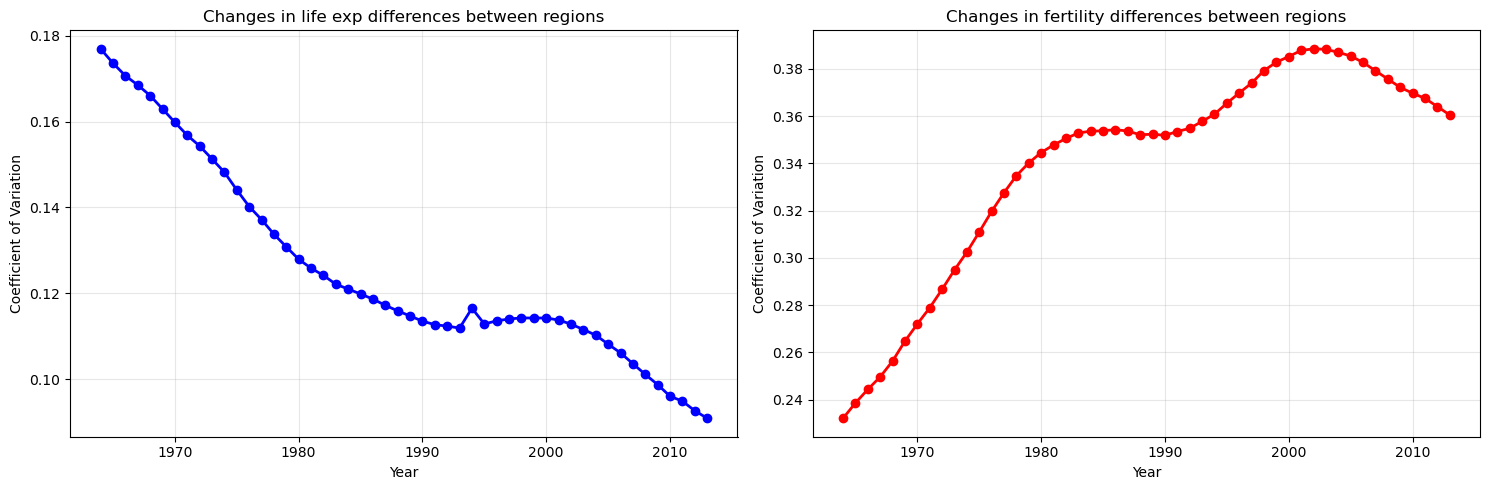


Divergence/Convergence Analysis:
Change in CV of life expectancy:0.1770 --> 0.0909 (-48.6%)
Change in CV of fertility: 0.2321 --> 0.3605 (+55.4%)
**Conclusion 1.2.1**: The life expectancy between regions tends to converge (differences narrowing).
**Conclusion 1.2.2**: The fertility between regions tends to diverge (differences widening).


In [11]:
## Sub-Question 1.2: By 2013, were the development trends across different regions showing signs of convergence, or divergence?

print("\n" + "="*140)
print("Sub-Question 1.2: By 2013, were the development trends across different regions showing signs of convergence, or divergence?")
print("="*140)

# Calculate annual coefficients of variation for each region
convergence_data = []

for year in years:
    year_data = df[df['Year'] == year]
    
    # Calculate coefficient of variation of life exp
    lifeexp_cv = year_data.groupby('Region')['lifeExp'].mean().std() / year_data.groupby('Region')['lifeExp'].mean().mean()
    
    # Calculate coefficient of variation of fertility
    fertility_cv = year_data.groupby('Region')['Fertility'].mean().std() / year_data.groupby('Region')['Fertility'].mean().mean()
    
    convergence_data.append({
        'Year': year,
        'LifeExp_CV': lifeexp_cv,
        'Fertility_CV': fertility_cv
    })

convergence_df = pd.DataFrame(convergence_data)

# Visualize the trend of convergence/divergence
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left plot: coefficient of variation of life exp
axes[0].plot(convergence_df['Year'], convergence_df['LifeExp_CV'], 
             linewidth=2, color='blue', marker='o')
axes[0].set_title('Changes in life exp differences between regions')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Coefficient of Variation')
axes[0].grid(True, alpha=0.3)

# Right plot: coefficient of variation of fertility
axes[1].plot(convergence_df['Year'], convergence_df['Fertility_CV'], 
             linewidth=2, color='red', marker='o')
axes[1].set_title('Changes in fertility differences between regions')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Coefficient of Variation')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analyze the trend
initial_lifeexp_cv = convergence_df[convergence_df['Year'] == 1964]['LifeExp_CV'].values[0]
final_lifeexp_cv = convergence_df[convergence_df['Year'] == 2013]['LifeExp_CV'].values[0]
lifeexp_change_pct = (final_lifeexp_cv - initial_lifeexp_cv) / initial_lifeexp_cv * 100

initial_fertility_cv = convergence_df[convergence_df['Year'] == 1964]['Fertility_CV'].values[0]
final_fertility_cv = convergence_df[convergence_df['Year'] == 2013]['Fertility_CV'].values[0]
fertility_change_pct = (final_fertility_cv - initial_fertility_cv) / initial_fertility_cv * 100

print(f"\nDivergence/Convergence Analysis:")
print(f"Change in CV of life expectancy:{initial_lifeexp_cv:.4f} --> {final_lifeexp_cv:.4f} ({lifeexp_change_pct:+.1f}%)")
print(f"Change in CV of fertility: {initial_fertility_cv:.4f} --> {final_fertility_cv:.4f} ({fertility_change_pct:+.1f}%)")

if lifeexp_change_pct < 0:
    print("**Conclusion 1.2.1**: The life expectancy between regions tends to converge (differences narrowing).")
else:
    print("**Conclusion 1.2.1**: The life expectancy between regions tends to diverge (differences widening).")

if fertility_change_pct < 0:
    print("**Conclusion 1.2.2**: The fertility between regions tends to converge (differences narrowing).")
else:
    print("**Conclusion 1.2.2**: The fertility between regions tends to diverge (differences widening).")

#### _<span style="color:Blue">SubQ Set 2: Regional disparities, correlations, pattern & trend?</span>_


Sub-Question 2.1: Which countries experienced the most dramatic increase in life expectancy alongside a sharp decrease in fertility over the period?

Top 10 countries with the most significant changes:


,Country,Region,LifeExp_Change,Fertility_Change,Change_Magnitude
111,Maldives,South Asia,39.008,4.923,48.854
19,Bhutan,South Asia,34.467,4.438,43.343
180,Tunisia,Middle East & North Africa,30.970,5.099,41.168
133,Oman,Middle East & North Africa,30.657,4.410,39.477
28,Cambodia,East Asia & Pacific,30.016,4.048,38.112
103,Libya,Middle East & North Africa,26.411,5.320,37.051
152,Saudi Arabia,Middle East & North Africa,27.698,4.613,36.924
83,Iran,Middle East & North Africa,26.875,4.948,36.771
195,Western Sahara,Middle East & North Africa,27.884,4.199,36.282
125,Nepal,South Asia,28.339,3.697,35.733


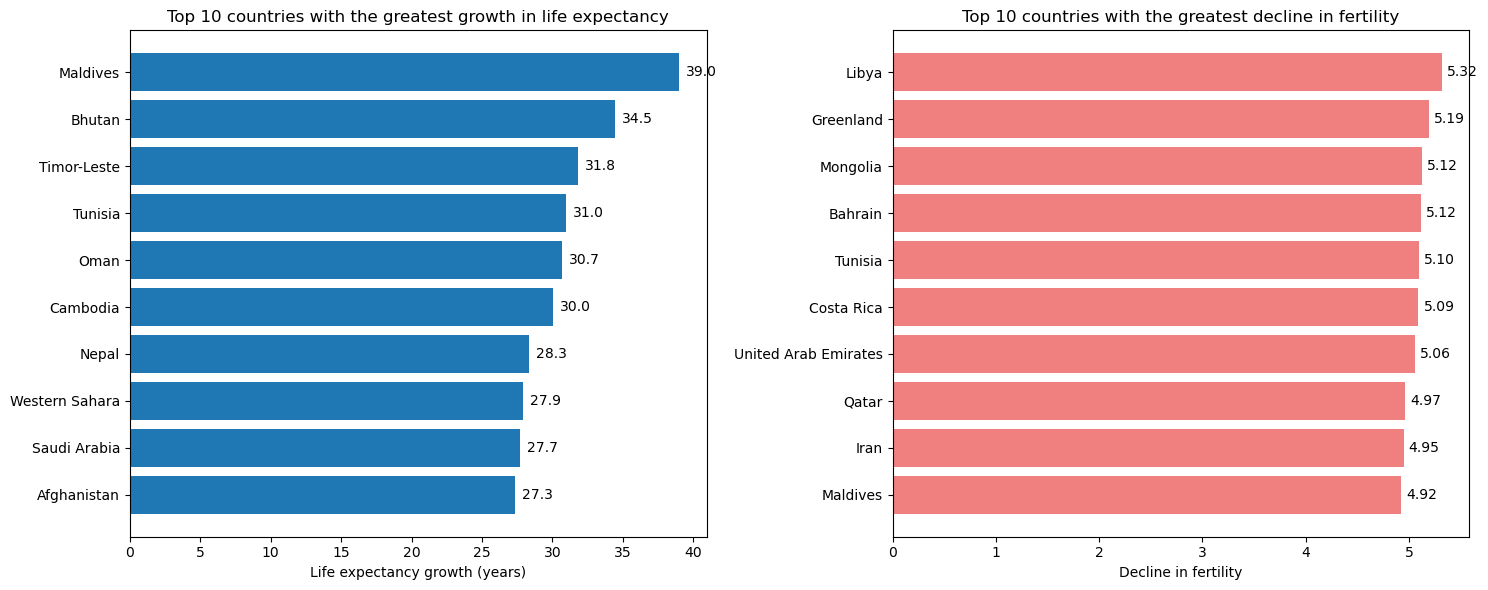


Countries that outstand in both indicators: {'Tunisia'}


In [12]:
# Sub-Question 2.1: Which countries demonstrated the most typical transformation pattern of dramatic increase in life expectancy alongside a sharp decrease in fertility over the 50-year period?

print("\n" + "="*150)
print("Sub-Question 2.1: Which countries experienced the most dramatic increase in life expectancy alongside a sharp decrease in fertility over the period?")
print("="*150)

country_changes = []

for country in df['Country'].unique():
    country_data = df[df['Country'] == country].sort_values('Year')
    
    if len(country_data) > 1:
        early_data = country_data[country_data['Year'] == 1964]
        late_data = country_data[country_data['Year'] == 2013]
        
        if len(early_data) > 0 and len(late_data) > 0:
            lifeexp_change = late_data['lifeExp'].values[0] - early_data['lifeExp'].values[0]
            fertility_change = early_data['Fertility'].values[0] - late_data['Fertility'].values[0]  # decline in fertility is calculated as a positive value.
            
            # Calculte the change magnitude index
            if fertility_change > 0:  # only consider countries whose fertilities dropped
                change_magnitude = lifeexp_change + fertility_change * 2
                
                country_changes.append({
                    'Country': country,
                    'Region': early_data['Region'].values[0],
                    'LifeExp_1964': early_data['lifeExp'].values[0],
                    'LifeExp_2013': late_data['lifeExp'].values[0],
                    'LifeExp_Change': lifeexp_change,
                    'Fertility_1964': early_data['Fertility'].values[0],
                    'Fertility_2013': late_data['Fertility'].values[0],
                    'Fertility_Change': fertility_change,
                    'Change_Magnitude': change_magnitude
                })

country_changes_df = pd.DataFrame(country_changes)

# Find top 10 countries with the most significant changes
top_countries = country_changes_df.sort_values('Change_Magnitude', ascending=False).head(10)
print("\nTop 10 countries with the most significant changes:")
display(top_countries[['Country', 'Region', 
                       'LifeExp_Change', 'Fertility_Change', 
                       'Change_Magnitude']])

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left plot: countries with the greatest growth in life exp
top_lifeexp = country_changes_df.sort_values('LifeExp_Change', ascending=False).head(10)
bars1 = axes[0].barh(range(len(top_lifeexp)), top_lifeexp['LifeExp_Change'].values)
axes[0].set_yticks(range(len(top_lifeexp)))
axes[0].set_yticklabels(top_lifeexp['Country'])
axes[0].set_xlabel('Life expectancy growth (years)')
axes[0].set_title('Top 10 countries with the greatest growth in life expectancy')
axes[0].invert_yaxis()

# Add value labels to bars
for i, (bar, value) in enumerate(zip(bars1, top_lifeexp['LifeExp_Change'].values)):
    axes[0].text(value + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{value:.1f}', va='center')

# Right plot: countries with the greatest decline in fertility
top_fertility = country_changes_df.sort_values('Fertility_Change', ascending=False).head(10)
bars2 = axes[1].barh(range(len(top_fertility)), top_fertility['Fertility_Change'].values, color='lightcoral')
axes[1].set_yticks(range(len(top_fertility)))
axes[1].set_yticklabels(top_fertility['Country'])
axes[1].set_xlabel('Decline in fertility')
axes[1].set_title('Top 10 countries with the greatest decline in fertility')
axes[1].invert_yaxis()

# Add value labels to bars
for i, (bar, value) in enumerate(zip(bars2, top_fertility['Fertility_Change'].values)):
    axes[1].text(value + 0.05, bar.get_y() + bar.get_height()/2, 
                f'{value:.2f}', va='center')

plt.tight_layout()
plt.show()

# Find the countries in both categories
top_lifeexp_countries = set(top_lifeexp['Country'].head(5))
top_fertility_countries = set(top_fertility['Country'].head(5))
common_countries = top_lifeexp_countries.intersection(top_fertility_countries)

print(f"\nCountries that outstand in both indicators: {common_countries if common_countries else 'None'}")

Sub-Question 2.2: Which regions developed most from 1963-2012?

Regional Development Ranking (based on increase in life expectancy and decrease in fertility):


,Region,LifeExp_Change,Fertility_Change,Development_Score
4,South Asia,25.310875,3.747000,32.804875
3,Middle East & North Africa,21.139333,4.249476,29.638286
1,East Asia & Pacific,17.279290,3.269970,23.819230
0,America,14.624575,3.316625,21.257825
5,Sub-Saharan Africa,15.365551,1.992041,19.349633
2,Europe & Central Asia,8.268046,1.525861,11.319768


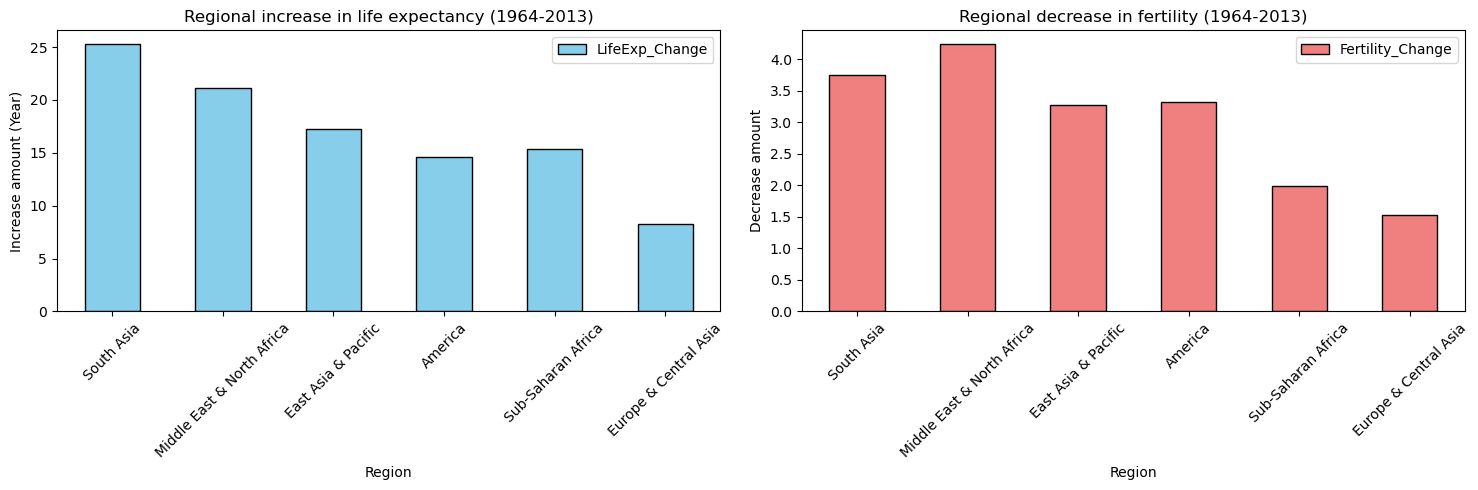


Most developed region: South Asia
Increase in life expectancy: 25.3 years
Decrease in fertility: 3.75


In [13]:
## Sub-Question 2.2: Which region developed most from 1963-2012?
print("="*100)
print("Sub-Question 2.2: Which regions developed most from 1963-2012?")
print("="*100)

# Calculate changes in life expectancy and fertility for each region
region_changes = []

for region in regions:
    region_data = df[df['Region'] == region]
    early_data = region_data[region_data['Year'] == 1964]
    late_data = region_data[region_data['Year'] == 2013]
    
    if len(early_data) > 0 and len(late_data) > 0:
        lifeexp_change = late_data['lifeExp'].mean() - early_data['lifeExp'].mean()
        fertility_change = early_data['Fertility'].mean() - late_data['Fertility'].mean()  # consider drop in fertility as positive development
        
        # Create compound development score
        # Give higher weight to fertility change since life exp is also more sensitive to negative factors, e.g. war
        development_score = lifeexp_change + fertility_change * 2
        
        region_changes.append({
            'Region': region,
            'LifeExp_Change': lifeexp_change,
            'Fertility_Change': fertility_change,
            'Development_Score': development_score
        })

region_changes_df = pd.DataFrame(region_changes).sort_values('Development_Score', ascending=False)
print("\nRegional Development Ranking (based on increase in life expectancy and decrease in fertility):")
display(region_changes_df)

# Visualize the result
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left plot: increase in life expectancy
region_changes_df.plot(kind='bar', x='Region', y='LifeExp_Change', 
                       ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Regional increase in life expectancy (1964-2013)')
axes[0].set_ylabel('Increase amount (Year)')
axes[0].tick_params(axis='x', rotation=45)

# Right plot: decrease in fertility
region_changes_df.plot(kind='bar', x='Region', y='Fertility_Change', 
                       ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_title('Regional decrease in fertility (1964-2013)')
axes[1].set_ylabel('Decrease amount')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\nMost developed region: {region_changes_df.iloc[0]['Region']}")
print(f"Increase in life expectancy: {region_changes_df.iloc[0]['LifeExp_Change']:.1f} years")
print(f"Decrease in fertility: {region_changes_df.iloc[0]['Fertility_Change']:.2f}")


Sub-Question 2.3: Is there a stable negative correlation between fertility rates and life expectancy?
How does this relationship differ across regions?


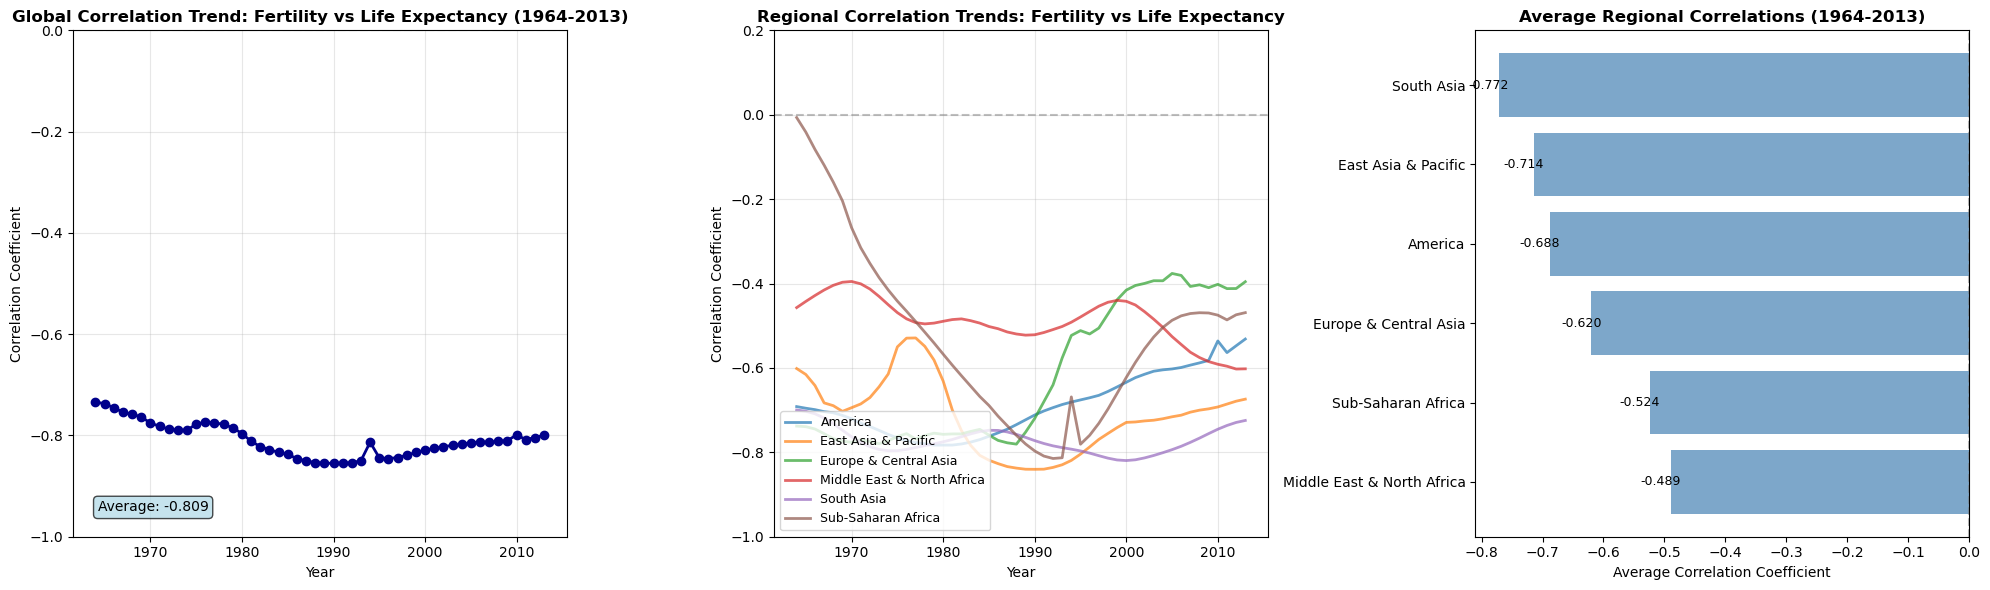


STATISTICAL ANALYSIS

Global Analysis (1964-2013):
  • Average correlation: -0.809
  • Years with negative correlation: 50/50 (100.0%)
  • Correlation range: [-0.855, -0.734]
  • Consistently negative every year: True

Regional Analysis (1964-2013):

  America:
    • Average correlation: -0.688
    • Years with negative correlation: 50/50 (100.0%)
    • Correlation range: [-0.783, -0.532]

  East Asia & Pacific:
    • Average correlation: -0.714
    • Years with negative correlation: 50/50 (100.0%)
    • Correlation range: [-0.840, -0.529]

  Europe & Central Asia:
    • Average correlation: -0.620
    • Years with negative correlation: 50/50 (100.0%)
    • Correlation range: [-0.781, -0.376]

  Middle East & North Africa:
    • Average correlation: -0.489
    • Years with negative correlation: 50/50 (100.0%)
    • Correlation range: [-0.603, -0.395]

  South Asia:
    • Average correlation: -0.772
    • Years with negative correlation: 50/50 (100.0%)
    • Correlation range: [-0.820,

In [14]:
## Sub-Question 2.3: Is there a stable negative correlation between fertility rates and life expectancy? How does this relationship differ across regions?

print("\n" + "="*150)
print("Sub-Question 2.3: Is there a stable negative correlation between fertility rates and life expectancy?")
print("How does this relationship differ across regions?")
print("="*150)

# 1. Calculate global correlation between fertility and life expectancy for each year
global_correlations = []

for year in years:
    year_data = df[df['Year'] == year]
    if len(year_data) >= 2:  # Need at least 2 data points for correlation
        correlation = year_data['Fertility'].corr(year_data['lifeExp'])
        global_correlations.append({
            'Year': year,
            'Global_Correlation': correlation
        })

global_corr_df = pd.DataFrame(global_correlations)

# 2. Calculate regional correlations for each year
regional_correlations_by_year = []

for year in years:
    year_data = df[df['Year'] == year]
    for region in regions:
        region_data = year_data[year_data['Region'] == region]
        if len(region_data) >= 2:  # Need at least 2 data points for correlation
            correlation = region_data['Fertility'].corr(region_data['lifeExp'])
            regional_correlations_by_year.append({
                'Year': year,
                'Region': region,
                'Regional_Correlation': correlation
            })

regional_corr_df = pd.DataFrame(regional_correlations_by_year)

# 3. Calculate average correlation for each region over the entire period
regional_avg_corr = regional_corr_df.groupby('Region')['Regional_Correlation'].mean().reset_index()
regional_avg_corr = regional_avg_corr.sort_values('Regional_Correlation')

# 4. Visualize
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Global correlation trend over time
axes[0].plot(global_corr_df['Year'], global_corr_df['Global_Correlation'], 
             linewidth=2, color='darkblue', marker='o')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Global Correlation Trend: Fertility vs Life Expectancy (1964-2013)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Correlation Coefficient')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([-1, 0])  # Correlation is expected to be negative

# Add text annotation for the average global correlation
avg_global_corr = global_corr_df['Global_Correlation'].mean()
axes[0].text(0.05, 0.05, f'Average: {avg_global_corr:.3f}', 
             transform=axes[0].transAxes, fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))

# Plot 2: Regional correlation trends over time
for region in regions:
    region_data = regional_corr_df[regional_corr_df['Region'] == region]
    axes[1].plot(region_data['Year'], region_data['Regional_Correlation'], 
                 linewidth=2, alpha=0.7, label=region)

axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Regional Correlation Trends: Fertility vs Life Expectancy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Correlation Coefficient')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='lower left', fontsize=9)
axes[1].set_ylim([-1, 0.2])  # Slight positive margin for some regions

# Plot 3: Average regional correlations (bar chart)
bars = axes[2].barh(range(len(regional_avg_corr)), regional_avg_corr['Regional_Correlation'], 
                    color='steelblue', alpha=0.7)
axes[2].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_yticks(range(len(regional_avg_corr)))
axes[2].set_yticklabels(regional_avg_corr['Region'])
axes[2].set_title('Average Regional Correlations (1964-2013)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Average Correlation Coefficient')
axes[2].invert_yaxis()  # Highest correlation at the top

# Add value labels to bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    axes[2].text(width + (0.01 if width >= 0 else -0.05), bar.get_y() + bar.get_height()/2,
                f'{width:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 5. Statistical analysis
print("\n" + "="*80)
print("STATISTICAL ANALYSIS")
print("="*80)

# Calculate percentage of years with negative correlation globally
negative_years_global = (global_corr_df['Global_Correlation'] < 0).sum()
total_years_global = len(global_corr_df)
percent_negative_global = negative_years_global / total_years_global * 100

print(f"\nGlobal Analysis (1964-2013):")
print(f"  • Average correlation: {avg_global_corr:.3f}")
print(f"  • Years with negative correlation: {negative_years_global}/{total_years_global} ({percent_negative_global:.1f}%)")
print(f"  • Correlation range: [{global_corr_df['Global_Correlation'].min():.3f}, {global_corr_df['Global_Correlation'].max():.3f}]")

# Check if correlation is consistently negative (all years)
is_consistently_negative_global = all(global_corr_df['Global_Correlation'] < 0)
print(f"  • Consistently negative every year: {is_consistently_negative_global}")

# Regional analysis
print(f"\nRegional Analysis (1964-2013):")
for region in regions:
    region_avg = regional_avg_corr[regional_avg_corr['Region'] == region]['Regional_Correlation'].values[0]
    region_data = regional_corr_df[regional_corr_df['Region'] == region]
    negative_years_region = (region_data['Regional_Correlation'] < 0).sum()
    total_years_region = len(region_data)
    percent_negative_region = negative_years_region / total_years_region * 100
    
    print(f"\n  {region}:")
    print(f"    • Average correlation: {region_avg:.3f}")
    print(f"    • Years with negative correlation: {negative_years_region}/{total_years_region} ({percent_negative_region:.1f}%)")
    print(f"    • Correlation range: [{region_data['Regional_Correlation'].min():.3f}, {region_data['Regional_Correlation'].max():.3f}]")

# 6. Identify regions with strongest and weakest negative correlations
strongest_negative_region = regional_avg_corr.iloc[0]  # Most negative (lowest value)
weakest_negative_region = regional_avg_corr.iloc[-1]   # Least negative (highest value)

print(f"\n" + "="*80)
print("KEY FINDINGS")
print("="*80)

print(f"\n1. Global Pattern:")
print(f"   The correlation between fertility rates and life expectancy is {'' if avg_global_corr < 0 else 'not '}negative on average.")
if avg_global_corr < 0:
    print(f"   The average global correlation of {avg_global_corr:.3f} indicates a moderate negative relationship.")
print(f"   The correlation remained negative in {percent_negative_global:.1f}% of the years.")

print(f"\n2. Regional Differences:")
print(f"   • Strongest negative correlation: {strongest_negative_region['Region']} (avg: {strongest_negative_region['Regional_Correlation']:.3f})")
print(f"   • Weakest negative correlation: {weakest_negative_region['Region']} (avg: {weakest_negative_region['Regional_Correlation']:.3f})")

print(f"\n3. Temporal Stability:")
# Check stability by calculating standard deviation of correlations
global_std = global_corr_df['Global_Correlation'].std()
print(f"   • Global correlation stability (std dev): {global_std:.3f}")
if global_std < 0.1:
    print(f"   • Interpretation: The global correlation is relatively stable over time.")
else:
    print(f"   • Interpretation: The global correlation shows moderate variability over time.")

print(f"\n4. Regional Stability Comparison:")
regional_stability = []
for region in regions:
    region_data = regional_corr_df[regional_corr_df['Region'] == region]
    region_std = region_data['Regional_Correlation'].std()
    regional_stability.append({
        'Region': region,
        'Std_Dev': region_std
    })
regional_stability_df = pd.DataFrame(regional_stability).sort_values('Std_Dev')
print("   Regions ordered by correlation stability (lowest std dev = most stable):")
for idx, row in regional_stability_df.iterrows():
    print(f"     {row['Region']}: {row['Std_Dev']:.3f}")

# 7. Statistical test for difference between regions
print(f"\n" + "="*80)
print("STATISTICAL SIGNIFICANCE TEST")
print("="*80)

# Perform ANOVA test to check if regional differences are statistically significant
import scipy.stats as stats

# Prepare data for ANOVA
region_corr_data = []
for region in regions:
    region_data = regional_corr_df[regional_corr_df['Region'] == region]['Regional_Correlation'].dropna()
    region_corr_data.append(region_data)

# Check if we have enough data for ANOVA
if all(len(data) >= 2 for data in region_corr_data):
    f_stat, p_value = stats.f_oneway(*region_corr_data)
    print(f"\nOne-way ANOVA test for regional correlation differences:")
    print(f"  F-statistic: {f_stat:.4f}")
    print(f"  p-value: {p_value:.4f}")
    
    if p_value < 0.05:
        print(f"  Interpretation: There is a statistically significant difference (p < 0.05)")
        print(f"                  in the fertility-life expectancy correlation across regions.")
    else:
        print(f"  Interpretation: No statistically significant difference (p ≥ 0.05)")
        print(f"                  in the fertility-life expectancy correlation across regions.")
else:
    print("  Insufficient data for ANOVA test (some regions have fewer than 2 valid correlation values).")

print(f"\n" + "="*80)
print("CONCLUSIONS")
print("="*80)

print(f"\n**Conclusion 2.3.1:**")
if avg_global_corr < -0.5:
    print("There is a strong and stable negative correlation between fertility rates and life expectancy globally.")
elif avg_global_corr < -0.3:
    print("There is a moderate negative correlation between fertility rates and life expectancy globally.")
elif avg_global_corr < 0:
    print("There is a weak negative correlation between fertility rates and life expectancy globally.")
else:
    print("There is no consistent negative correlation between fertility rates and life expectancy globally.")

print(f"\n**Conclusion 2.3.2:**")
if p_value < 0.05:
    print("The strength of the fertility-life expectancy correlation differs significantly across regions.")
    print(f"The correlation is strongest in {strongest_negative_region['Region']} and weakest in {weakest_negative_region['Region']}.")
else:
    print("The fertility-life expectancy correlation does not differ significantly across regions.")

print(f"\n**Conclusion 2.3.3:**")
if is_consistently_negative_global and percent_negative_global > 90:
    print("The negative correlation is highly consistent over time, observed in most years across the 50-year period.")
elif percent_negative_global > 70:
    print("The negative correlation is generally consistent, but shows some variability in certain years.")
else:
    print("The correlation shows significant variability over time, with periods of both negative and positive relationships.")